In [2]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# Get ArtemisBLEController object
ble = get_ble_controller()
# Connect to the Artemis Device
ble.connect()

2025-03-26 15:10:33,206 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:e0:ec:f0:72:02
2025-03-26 15:10:37,647 | INFO     |: Connected to c0:e0:ec:f0:72:02


In [25]:
# Global lists to store stunt log data
stunt_time = []   # Time (ms)
stunt_tof = []    # TOF distance (mm)
stunt_kf = []     # KF distance (mm)
stunt_yaw = []    # Yaw (degrees)
stunt_notification_count = 0

def stunt_notification_handler(sender: int, data: bytearray):
    global stunt_notification_count, stunt_time, stunt_tof, stunt_kf, stunt_yaw
    try:
        message = data.decode("utf-8").strip()
        # Expected message format: "T:<time>|T1:<tof>|X:<kf>|Y:<yaw>"
        if message.startswith("T:"):
            parts = message.split("|")
            if len(parts) < 4:
                print(f"Incomplete stunt data: {message}")
                return
            t = float(parts[0].split(":")[1])
            tof = float(parts[1].split(":")[1])
            kf = float(parts[2].split(":")[1])
            yaw = float(parts[3].split(":")[1])
            stunt_time.append(t)
            stunt_tof.append(tof)
            stunt_kf.append(kf)
            stunt_yaw.append(yaw)
            stunt_notification_count += 1
            print(f"Stunt Data #{stunt_notification_count}: {message}")
        else:
            print(f"Other notification: {message}")
    except Exception as ex:
        print("Error parsing stunt notification:", ex)
# Subscribe to notifications (assuming your device uses the same RX characteristic for notifications)
ble.start_notify(ble.uuid['RX_STRING'], stunt_notification_handler)

In [30]:
# Step 1: Set PID Gains
ble.send_command(CMD.SET_PID_GAINS, "0.5|0.00025|0.15|900")

Other notification: PID Gains Updated: Kp=0.500, Ki=0.000, Kd=0.150, Setpoint=900.000


In [ ]:
myKp = 5
myKi = 0.005
myKd = 10
mySetpoint = 0.0

# Format: "Kp|Ki|Kd|Setpoint"
ble.send_command(CMD.SET_ORIENTATION_GAINS,
                 f"{myKp}|{myKi}|{myKd}|{mySetpoint}")

In [31]:
ble.send_command(CMD.SET_KF_PARAMETERS, "30|0|0")

Other notification: KF Params Updated: sigma_pos=0.000, sigma_vel=30.000, sigma_z=0.000


In [32]:
# Step 2: Start PID Control Test
# Instruct the device to run PID control for 5000 ms (5 seconds).
ble.send_command(CMD.START_PID_CONTROL, "3000")
# Wait a bit longer than the test duration to ensure the test completes.

Other notification: Starting PID control for 3000 ms


In [33]:
# Send the GET_STUNT_DATA command to request the logged data
ble.send_command(CMD.GET_STUNT_DATA, "")

Stunt Data #2001: T:196296|T1:0.000|X:8123.374|Y:-24.626
Stunt Data #2002: T:196307|T1:0.000|X:8139.695|Y:-24.626
Stunt Data #2003: T:196316|T1:0.000|X:8155.764|Y:-24.626
Stunt Data #2004: T:196327|T1:0.000|X:8171.582|Y:-24.626
Stunt Data #2005: T:196338|T1:0.000|X:8187.149|Y:-24.626
Stunt Data #2006: T:196349|T1:0.000|X:8202.470|Y:-24.626
Stunt Data #2007: T:196370|T1:0.000|X:8217.545|Y:-24.626
Stunt Data #2008: T:196378|T1:0.000|X:8232.376|Y:-24.626
Stunt Data #2009: T:196384|T1:0.000|X:8246.966|Y:-24.626
Stunt Data #2010: T:196411|T1:0.000|X:8261.316|Y:-24.626
Stunt Data #2011: T:196419|T1:0.000|X:8275.427|Y:-24.626
Stunt Data #2012: T:196424|T1:0.000|X:8289.302|Y:-24.626
Stunt Data #2013: T:196437|T1:0.000|X:8302.943|Y:-24.626
Stunt Data #2014: T:196443|T1:0.000|X:8316.351|Y:-24.626
Stunt Data #2015: T:196449|T1:0.000|X:8329.528|Y:-24.626
Stunt Data #2016: T:196454|T1:0.000|X:8342.476|Y:-24.626
Stunt Data #2017: T:196465|T1:0.000|X:8355.197|Y:-24.626
Stunt Data #2018: T:196476|T1:0

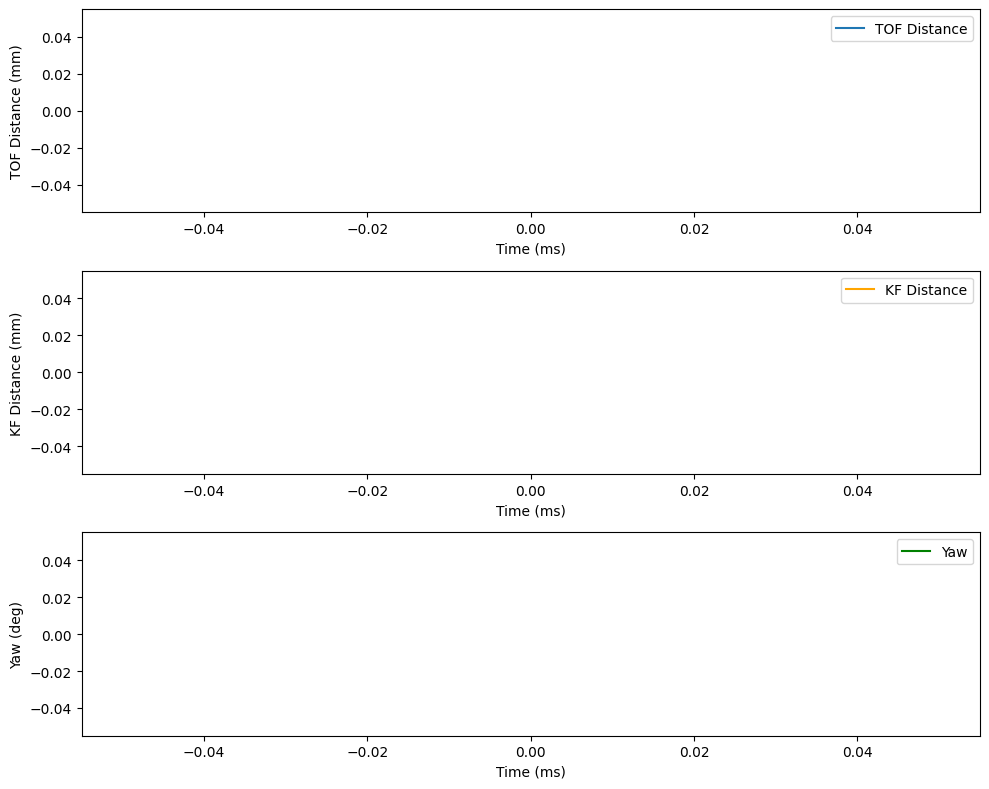

In [17]:
import matplotlib.pyplot as plt

# Create a figure with three subplots
plt.figure(figsize=(10, 8))

plt.subplot(3,1,1)
plt.plot(stunt_time, stunt_tof, label='TOF Distance')
plt.xlabel('Time (ms)')
plt.ylabel('TOF Distance (mm)')
plt.legend()

plt.subplot(3,1,2)
plt.plot(stunt_time, stunt_kf, label='KF Distance', color='orange')
plt.xlabel('Time (ms)')
plt.ylabel('KF Distance (mm)')
plt.legend()

plt.subplot(3,1,3)
plt.plot(stunt_time, stunt_yaw, label='Yaw', color='green')
plt.xlabel('Time (ms)')
plt.ylabel('Yaw (deg)')
plt.legend()

plt.tight_layout()
plt.show()
